# PINN for the logistic ODE (§4.2)

$$\frac{du}{dt} = r\,u\left(1-\frac{u}{K}\right),\quad u(0)=u_0,
\qquad u(t)=\frac{K}{1+(K/u_0-1)e^{-rt}}$$

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

r, K, u0, T = 1.5, 2.0, 0.1, 6.0

def exact(t):
    return K / (1 + (K / u0 - 1) * torch.exp(-r * t))

In [2]:
class MLP(nn.Module):
    def __init__(self, width=32, depth=3):
        super().__init__()
        layers = [nn.Linear(1, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, t):
        return u0 + t * self.net(2 * t / T - 1)   # hard IC: u(0) = u0

In [3]:
def residual_loss(model, t):
    t = t.clone().requires_grad_(True)
    u = model(t)
    du = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    return ((du - r * u * (1 - u / K)) ** 2).mean()


model = MLP()
opt = torch.optim.Adam(model.parameters(), lr=2e-3)

for epoch in range(8001):
    t_col = torch.rand(200, 1) * T
    loss = residual_loss(model, t_col)
    opt.zero_grad()
    loss.backward()
    opt.step()
    if epoch % 1000 == 0:
        print(f"epoch {epoch:5d}   loss = {loss.item():.3e}")

epoch     0   loss = 9.893e-01


epoch  1000   loss = 4.315e-03


epoch  2000   loss = 4.543e-03


epoch  3000   loss = 6.258e-03


epoch  4000   loss = 5.297e-03


epoch  5000   loss = 1.703e-04


epoch  6000   loss = 2.658e-04


epoch  7000   loss = 9.077e-06


epoch  8000   loss = 3.071e-06


max abs error: 5.11e-03


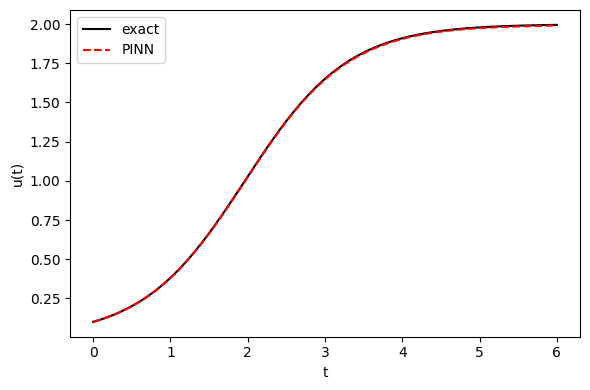

In [4]:
t_test = torch.linspace(0, T, 300).reshape(-1, 1)
with torch.no_grad():
    u_pred = model(t_test)
u_true = exact(t_test)

print(f"max abs error: {(u_pred - u_true).abs().max().item():.2e}")

plt.figure(figsize=(6, 4))
plt.plot(t_test, u_true, "k-", label="exact")
plt.plot(t_test, u_pred, "r--", label="PINN")
plt.xlabel("t"); plt.ylabel("u(t)"); plt.legend()
plt.tight_layout(); plt.show()